In [1]:
!pip install mteb

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.0/288.0 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127

In [2]:
!pip install torch torchvision torchaudio

In [3]:
import numpy as np
import json
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from mteb import MTEB
from sentence_transformers import SentenceTransformer, util
import torch
from sentence_transformers import InputExample
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader
from sentence_transformers import losses
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import classification_report
import os
import datetime
from sentence_transformers.evaluation import TripletEvaluator

from transformers import T5ForConditionalGeneration, T5Tokenizer
import re

from tqdm import tqdm




In [6]:
# !nvidia-smi

Mon Apr 14 05:39:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             43W /  400W |       5MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [119]:

print(torch.cuda.is_available())


True


In [9]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
data_file= "/content/drive/MyDrive/YXIR/dataset_big_patent_v3.json"
with open(data_file , "r", encoding="utf-8") as f:
    data = json.load(f)
# data

In [11]:
df = pd.DataFrame(data)

In [12]:

df.columns

Index(['anchor', 'query', 'positive', 'negative'], dtype='object')

In [13]:
df['anchor_len'] = df['anchor'].apply(lambda x: len(x.split()))
df['query_len'] = df['query'].apply(lambda x: len(x.split()))
df['pos_len'] = df['positive'].apply(lambda x: len(x.split()))
df['neg_len'] = df['negative'].apply(lambda x: len(x.split()))

In [14]:
print(df[['anchor_len', 'query_len', 'pos_len', 'neg_len']].mean())

anchor_len    3004.835671
query_len       18.100200
pos_len        267.509018
neg_len        270.931864
dtype: float64


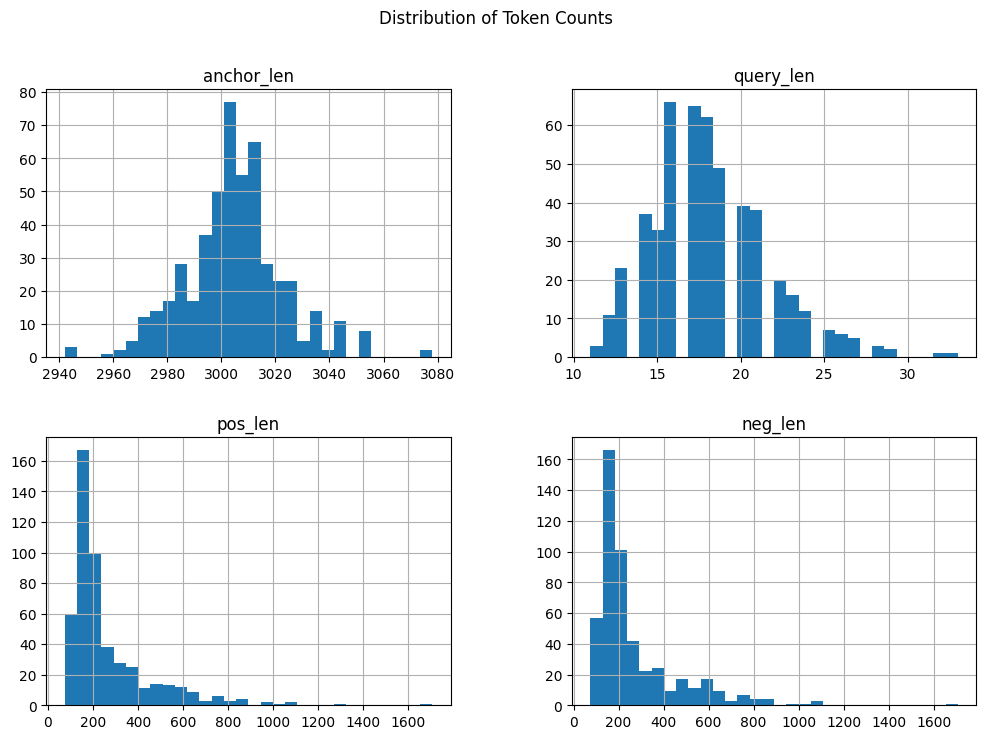

In [15]:
df[['anchor_len', 'query_len', 'pos_len', 'neg_len']].hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of Token Counts")
plt.show()

### Data preprocessing ..

In [16]:
# def clean_ocr_noise(text):
#     text = text.encode().decode('unicode_escape')
#     text = re.sub(r'\n+', ' ', text)
#     return text.strip()

def clean_ocr_noise(text):
    # Replace double newlines with ". " to preserve sentence boundaries
    text = re.sub(r'\n+', '. ', text)
    # Keep Unicode symbols (e.g., \u2248 → ≈) but ensure they’re decoded
    text = text.encode().decode('unicode_escape')
    return text.strip()

In [17]:
text = "fr \u2248 1 2 \u2062 L \n\n E eff"
cleaned_text = clean_ocr_noise(text)
print(cleaned_text)

fr â 1 2 â¢ L .  E eff


In [25]:

model = SentenceTransformer("intfloat/e5-base-v2")

raw_text = "fr \u2248 1 2 \u2062 L \n\n E eff"
cleaned_text = clean_ocr_noise(raw_text)

raw_emb = model.encode(raw_text)
cleaned_emb = model.encode(cleaned_text)


similarity = util.cos_sim(raw_emb, cleaned_emb).item()
print(f"Similarity between raw and cleaned: {similarity:.3f}")

related_text = "fr around 1 2..L E eff"
related_emb = model.encode(related_text)
raw_sim = util.cos_sim(raw_emb, related_emb).item()
cleaned_sim = util.cos_sim(cleaned_emb, related_emb).item()
print(f"Raw vs. related: {raw_sim:.3f}, Cleaned vs. related: {cleaned_sim:.3f}")

Similarity between raw and cleaned: 0.945
Raw vs. related: 0.935, Cleaned vs. related: 0.937


&rarr; maybe we skip on preprocessing for instance

In [27]:
#attempt on dissecting the anchor text ...

def section_anchor(anchor):
    # find potential all-caps headers
    pattern = r'\b[A-Z\s\-]+(?=\s*\[\d+\]|\s+[A-Za-z0-9])'
    headers = re.findall(pattern, anchor)

    # filter headers: must be at least 10 chars..
    headers = [header.strip() for header in headers if len(header) >= 10]

    if not headers:
        return {"FULL_TEXT": anchor.strip()}

    # create pattern to split on headers
    split_pattern = r'\b(?:' + '|'.join(map(re.escape, headers)) + r')\b'

    # split the text based on headers
    sections = re.split(split_pattern, anchor)

    # pair headers with their sections
    section_dict = {}
    for i, header in enumerate(headers):
        section_text = sections[i + 1].strip() if i + 1 < len(sections) else ""
        if section_text:
            section_dict[header] = section_text

    return section_dict



In [28]:
anchor = df.iloc[1]['anchor']

In [29]:
anchor

'RELATED APPLICATIONS This application claims the benefit of priority to U.S. Provisional Application No. 60/791,004, filed Apr. 11, 2006, and is a continuation-in-part of U.S. application Ser. No. 11/652,272, filed Jan. 11, 2007, which claims the benefit of priority to U.S. Provisional Application No. 60/758,042, filed Jan. 11, 2006, and U.S. Provisional Application No. 60/790,921, filed Apr. 11, 2006, and is a continuation-in-part of U.S. application Ser. No. 10/730,355, filed Dec. 8, 2003, which claims the benefit of priority to U.S. Provisional Application No. 60/431,487, filed Dec. 9, 2002, the disclosures of which are incorporated herein by reference in their entirety. FIELD OF THE INVENTION This invention relates to apparatus and methods for harvesting energy from the environment and other sources external to the harvester and converting it to useful electrical energy. The present invention generally relates to implantable stimulator systems and methods, and more particularly re

In [30]:
sectioned_anchor = section_anchor(anchor)

In [31]:
print(list(sectioned_anchor.keys()))
for header, text in sectioned_anchor.items():
    print(f"{header}:\n{text}\n")

['RELATED APPLICATIONS', 'FIELD OF THE INVENTION', 'BACKGROUND OF THE INVENTION', 'SUMMARY OF THE INVENTION']
RELATED APPLICATIONS:
This application claims the benefit of priority to U.S. Provisional Application No. 60/791,004, filed Apr. 11, 2006, and is a continuation-in-part of U.S. application Ser. No. 11/652,272, filed Jan. 11, 2007, which claims the benefit of priority to U.S. Provisional Application No. 60/758,042, filed Jan. 11, 2006, and U.S. Provisional Application No. 60/790,921, filed Apr. 11, 2006, and is a continuation-in-part of U.S. application Ser. No. 10/730,355, filed Dec. 8, 2003, which claims the benefit of priority to U.S. Provisional Application No. 60/431,487, filed Dec. 9, 2002, the disclosures of which are incorporated herein by reference in their entirety.

FIELD OF THE INVENTION:
This invention relates to apparatus and methods for harvesting energy from the environment and other sources external to the harvester and converting it to useful electrical energy.

In [32]:
sectioned_data = [section_anchor(anchor) for anchor in df['anchor']]

sectioned_df = pd.DataFrame(sectioned_data)

In [33]:
sectioned_df

,RELATED APPLICATIONS,FIELD OF THE INVENTION,BACKGROUND OF THE INVENTION,SUMMARY OF THE INVENTION,OBJECTS OF THE INVENTION,DETAILED DESCRIPTION OF THE PREFERRED EMBODIMENTS,BYINGREDIENT EFFECT,SUBSTITUTEINGREDIENT,APPROXIMATE AMOUNTINGREDIENT,RELATED APPLICATION,...,FOLDABLE CHILD SUPPORT,PRIORITY CLAIMS,DETAILED DESCRIPTION OF THE PREFERRED EMBODIMENTS A,EXAMPLES AND CONTROLS EXAMPLE,SPRAY NOZZLE DESIGN FOR A,CROSS-REFERENCES TO OTHER APPLICATIONS,REFERENCE NUMBER,ION EXCHANGE FRACTION,PREPARATION OF MICRIN,PHARMACEUTICAL COMPOSITION
0,This application claims the benefit of priorit...,This invention relates to apparatus and method...,Energy harvesters are known that convert vibra...,In accordance with various embodiments of the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This application claims the benefit of priorit...,This invention relates to apparatus and method...,Energy harvesters are known that convert vibra...,In accordance with various embodiments of the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,This application claims the benefit of priorit...,This invention relates to apparatus and method...,Energy harvesters are known that convert vibra...,In accordance with various embodiments of the ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,I. Field of the Invention This invention relat...,The present invention is based on the unexpect...,It is therefore an object of the present inven...,While blocks containing buffers (including mag...,WEIGHT______________________________________So...,MATERIAL % BY WEIGHT__________________________...,IN % BY WEIGHT________________________________...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,1. Field of the Invention The present inventio...,NaN,NaN,NaN,NaN,NaN,NaN,The present application claims priority from U...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,NaN,NaN,NaN,NaN,NaN,"[0032] As used herein and in the claims, “comp...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
495,NaN,NaN,NaN,NaN,NaN,"[0032] As used herein and in the claims, “comp...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,[0001] This application is a continuation of U...,NaN,[0003] Currently dentists utilize a set of imp...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

for header in sectioned_df.columns:
    print(header)

All section headers:
RELATED APPLICATIONS
FIELD OF THE INVENTION
BACKGROUND OF THE INVENTION
SUMMARY OF THE INVENTION
OBJECTS OF THE INVENTION
DETAILED DESCRIPTION OF THE PREFERRED EMBODIMENTS
BYINGREDIENT EFFECT
SUBSTITUTEINGREDIENT
APPROXIMATE AMOUNTINGREDIENT
RELATED APPLICATION
OBJECTS AND SUMMARY OF THE INVENTION
BRIEF DESCRIPTION OF THE DRAWINGS
DETAILED DESCRIPTION OF THE PREFERRED EMBODIMENT
STATEMENT REGARDING FEDERALLY SPONSORED RESEARCH
CROSS-REFERENCE TO RELATED APPLICATIONS
BRIEF SUMMARY OF THE INVENTION
BRIEF DESCRIPTION OF THE SEVERAL VIEWS OF THE DRAWINGS
DETAILED DESCRIPTION OF THE INVENTION
DETAILED DESCRIPTION
SUMMARY OF THE INVENTION A
BRIEF DESCRIPTION OF THE DRAWING FIGURES
TOTAL WEIGHT
DESCRIPTION OF THE RELATED ART
DESCRIPTION OF THE PREFERRED EMBODIMENTS
DESCRIPTION OF THE INVENTION
TECHNICAL FIELD
CROSS REFERENCE TO RELATED APPLICATIONS
DETAILED DESCRIPTION OF EMBODIMENTS
CROSS REFERENCE TO RELATED APPLICATION
BRIEF DESCRIPTION OF THE INVENTION
BACKGROUND
CO-Q

&rarr; maybe DISCARD:


* Procedural/legal sections ( RELATED APPLICATIONS, PRIORITY CLAIMS)
* Metadata or references ( REFERENCE NUMBER, CROSS-REFERENCES)
* Non-descriptive or overly specific (CO-Q-Q-R-F-E-W-E-F-E-Q-Q-NH, LOT NO FORMULATION PH).
* Figures/drawings ( BRIEF DESCRIPTION OF THE DRAWINGS) unless we need visual context



### Approach 1 : Augment anchor with query



In [34]:
# def truncate_text(text, max_tokens=450):
#     tokens = tokenizer(text, truncation=True, max_length=max_tokens, return_tensors="pt")
#     return tokenizer.decode(tokens["input_ids"][0], skip_special_tokens=True)

def augment_anchor(query, anchor, separator=" "):
    return f"{query}{separator}{anchor}"


augmented_data = []

for idx, row in df.iterrows():
    augmented_anchor = augment_anchor(row["query"], row["anchor"])
    augmented_data.append({
        "augmented_anchor": augmented_anchor,
        "positive": row["positive"],
        "negative": row["negative"]
    })

augmented_df = pd.DataFrame(augmented_data)


In [35]:
augmented_df.iloc[1]['augmented_anchor']

'How does a magnetic energy harvester operate without an internal permanent magnet or local field source?, RELATED APPLICATIONS This application claims the benefit of priority to U.S. Provisional Application No. 60/791,004, filed Apr. 11, 2006, and is a continuation-in-part of U.S. application Ser. No. 11/652,272, filed Jan. 11, 2007, which claims the benefit of priority to U.S. Provisional Application No. 60/758,042, filed Jan. 11, 2006, and U.S. Provisional Application No. 60/790,921, filed Apr. 11, 2006, and is a continuation-in-part of U.S. application Ser. No. 10/730,355, filed Dec. 8, 2003, which claims the benefit of priority to U.S. Provisional Application No. 60/431,487, filed Dec. 9, 2002, the disclosures of which are incorporated herein by reference in their entirety. FIELD OF THE INVENTION This invention relates to apparatus and methods for harvesting energy from the environment and other sources external to the harvester and converting it to useful electrical energy. The p

In [36]:
train_df, test_df = train_test_split(augmented_df, test_size=0.2, random_state=42)


####zero shot peformances results using some EMs




The evaluator calls the models encode that tokenize (via its tokenizer) then genrate embedding uses a binary classification metric to assess the models performance on the triplet task:

accuracy = (number of triplets where sim(anchor, positive) > sim(anchor, negative)) / (total number of triplets)

In [126]:
model = SentenceTransformer("intfloat/e5-base-v2")

In [125]:
evaluator = TripletEvaluator(


    anchors = test_df["augmented_anchor"].tolist(),
    positives=test_df["positive"].tolist(),
    negatives=test_df["negative"].tolist(),
    similarity_fn_names=["cosine", "dot", "euclidean", "manhattan"],

    main_similarity_function= None, #tests on all

    show_progress_bar=True,
    write_csv=True


)

In [74]:
results = evaluator(model)


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [75]:
results

{'cosine_accuracy': 0.699999988079071,
 'dot_accuracy': 0.699999988079071,
 'euclidean_accuracy': 0.699999988079071,
 'manhattan_accuracy': 0.699999988079071,
 'max_accuracy': 0.699999988079071}

#### fine tuning peformances results using some EMs

In [127]:
train_examples = []
for idx, row in train_df.iterrows():
    train_examples.append(InputExample(
        texts=[row["augmented_anchor"], row["positive"], row["negative"]]
    ))


In [128]:
batch_size = 16
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size)

In [129]:
# model = SentenceTransformer('intfloat/e5-base-v2')


In [130]:
print("Model:", model._first_module().__class__.__name__)

print("\nModel config:")
print(model._first_module().auto_model.config)
print("\nPooling type:")
print(model[1])

sample_embedding = model.encode(["test sentence"])
print("\nEmbedding dimension:", sample_embedding.shape[1])

Model: Transformer

Model config:
BertConfig {
  "_attn_implementation_autoset": true,
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.50.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}


Pooling type:
Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': 

In [140]:
triplet_loss = losses.TripletLoss(
     model=model,
    distance_metric=losses.SiameseDistanceMetric.COSINE_DISTANCE,
     triplet_margin = 0.1
   )


In [141]:
# torch.cuda.empty_cache()

In [142]:
num_epochs = 10
warmup_steps = int(len(train_dataloader) * 0.1)

In [143]:
model.fit(
    train_objectives=[(train_dataloader, triplet_loss)],
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    show_progress_bar=True
)

Step,Training Loss


time:

In [144]:
evaluator = TripletEvaluator(
    anchors = test_df["augmented_anchor"].tolist(),
    positives=test_df["positive"].tolist(),
    negatives=test_df["negative"].tolist(),

    # margin=margin,
    show_progress_bar=True


)

In [145]:
results = evaluator(model)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [146]:
results

{'cosine_accuracy': 0.4300000071525574}

In [107]:
contrastive_loss = losses.ContrastiveLoss(
    model=model,
    distance_metric=losses.SiameseDistanceMetric.COSINE_DISTANCE,
    margin=0.5
)

In [108]:
train_samples = []
for _, row in test_df.iterrows():
    anchor = row["augmented_anchor"]
    positive = row["positive"]
    negative = row["negative"]
    # (QA, P)
    train_samples.append(InputExample(texts=[anchor, positive], label=1))
    # (QA, N)
    train_samples.append(InputExample(texts=[anchor, negative], label=0))

train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=16)

In [109]:
model.fit(
    train_objectives=[(train_dataloader, contrastive_loss)],
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    show_progress_bar=True
)




Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


In [110]:
evaluator = TripletEvaluator(


    anchors = test_df["augmented_anchor"].tolist(),
    positives=test_df["positive"].tolist(),
    negatives=test_df["negative"].tolist(),

)



In [111]:
evaluator(model)

{'cosine_accuracy': 0.9599999785423279}

In [114]:
anchor = test_df["augmented_anchor"].iloc[7]
positive = test_df["positive"].iloc[7]
negative = test_df["negative"].iloc[7]

In [115]:
anchor_emb = model.encode(anchor, convert_to_tensor=True)
positive_emb = model.encode(positive, convert_to_tensor=True)
negative_emb = model.encode(negative, convert_to_tensor=True)

# Compute cosine similarities
pos_similarity = util.cos_sim(anchor_emb, positive_emb).item()
neg_similarity = util.cos_sim(anchor_emb, negative_emb).item()

# Compute cosine distances (1 - similarity)
pos_distance = 1 - pos_similarity
neg_distance = 1 - neg_similarity

print(f"Cosine Sim (Anchor, Positive): {pos_similarity:.4f}")
print(f"Cosine Sim (Anchor, Negative): {neg_similarity:.4f}")
print(f"Cosine Dist (Anchor, Positive): {pos_distance:.4f}")
print(f"Cosine Dist (Anchor, Negative): {neg_distance:.4f}")
print(f"Positive pair is closer: {pos_distance < neg_distance}")

Cosine Sim (Anchor, Positive): 0.9305
Cosine Sim (Anchor, Negative): 0.8988
Cosine Dist (Anchor, Positive): 0.0695
Cosine Dist (Anchor, Negative): 0.1012
Positive pair is closer: True


In [116]:
# Prepare only positive pairs
train_samples = []
for anchor, positive, _ in zip(train_df["augmented_anchor"], train_df["positive"], train_df["negative"]):
    train_samples.append(InputExample(texts=[anchor, positive]))

train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=16)

# Define MNRL
mnrl_loss = losses.MultipleNegativesRankingLoss(model=model)

# Fine-tune
model.fit(
    train_objectives=[(train_dataloader, mnrl_loss)],
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    show_progress_bar=True
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


In [117]:
evaluator = TripletEvaluator(

    anchors = test_df["augmented_anchor"].tolist(),
    positives=test_df["positive"].tolist(),
    negatives=test_df["negative"].tolist(),

)


In [118]:
evaluator(model)

{'cosine_accuracy': 0.6299999952316284}

In [121]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
import numpy as np



embeddings = []
labels = []

for _, row in test_df.iterrows():
    anchor = row["augmented_anchor"]
    positive = row["positive"]
    negative = row["negative"]

    emb_anchor = model.encode(anchor)
    emb_positive = model.encode(positive)
    emb_negative = model.encode(negative)

    embeddings.extend([emb_anchor, emb_positive, emb_negative])
    labels.extend(["Anchor", "Positive", "Negative"])


embeddings = np.array(embeddings)


reducer = umap.UMAP(n_components=2, random_state=42)
reduced = reducer.fit_transform(embeddings)




/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


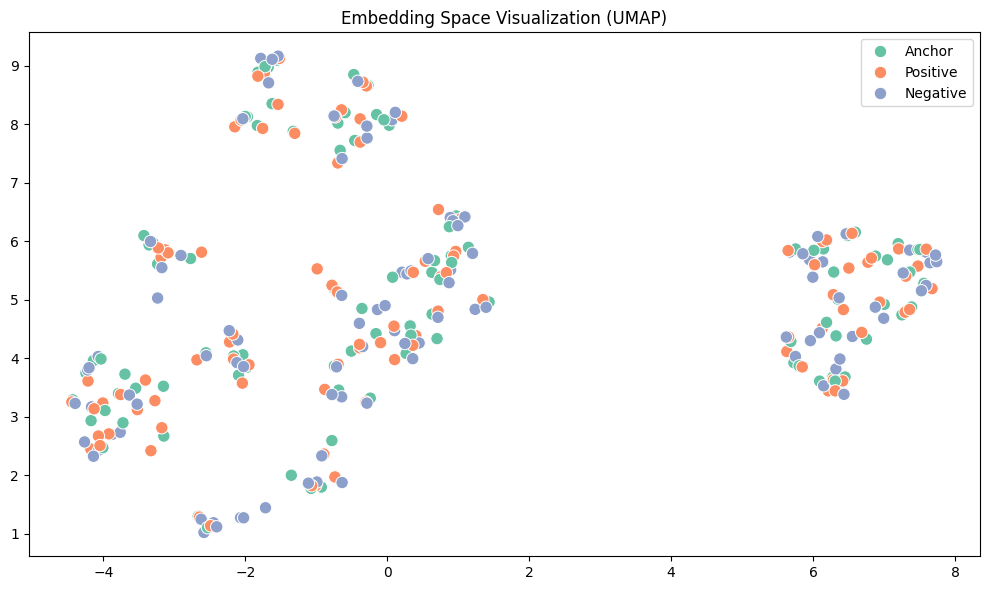

In [123]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, palette="Set2", s=80)
plt.title("Embedding Space Visualization (UMAP)")
plt.legend(loc='best')
plt.tight_layout()
plt.show()